# Notebook 05: Fabrication & Causality Analysis

**Detection Vectors 2 & 3 (Combined Weight: 50% of Manipulation Score)**

This notebook tackles the two most critical evidence vectors:

**Vector 2 — Fabrication Detection (25%)**: Did Trump make provably false claims
that moved markets? The March 23 "productive conversations" post is the smoking gun.

**Vector 3 — Intraday Causality (25%)**: Did the post come BEFORE the price move?
This is what separates correlation from causation.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')

COLORS = {
    'escalation': '#d62728',
    'de_escalation': '#2ca02c',
    'neutral': '#7f7f7f',
    'fabrication': '#ff7f0e',
    'oil_price': '#1f77b4',
    'denial': '#9467bd'
}

# Load data
master = pd.read_csv('../data/processed/master_dataset.csv')
master['date'] = pd.to_datetime(master['date'])

posts = pd.read_csv('../data/processed/posts_cleaned.csv')
posts['timestamp'] = pd.to_datetime(posts['timestamp'])
posts['date'] = pd.to_datetime(posts['date'])

gemini = pd.read_csv('../data/processed/gemini_classifications.csv')
gemini['date'] = pd.to_datetime(gemini['date'])

print('Data loaded.')

Data loaded.


## PART A: Fabrication Detection (Vector 2)

### The Smoking Gun: March 23, 2026

Trump posted about "productive conversations" with Iran → oil dropped 13%+
→ Iran's Foreign Ministry explicitly denied any talks, calling it
"fake news to manipulate the financial and oil markets."

This is textbook market manipulation: a false claim that moved markets,
where the counterparty explicitly identified it as manipulation.

In [3]:
# Document all fabrication evidence
fabrication_evidence = pd.DataFrame([
    {
        'date': '2026-03-23',
        'trump_claim': 'Productive conversations with Iran, hostilities resolving',
        'verification_status': 'PROVEN FALSE',
        'denial_source': 'Iranian Foreign Ministry, Tasnim News Agency, IRNA',
        'denial_summary': 'No negotiations held; called it fake news to manipulate oil markets',
        'price_impact_pct': -13.0,
        'fabrication_score': 100,
        'notes': 'Iran explicitly accused Trump of market manipulation'
    },
    {
        'date': '2026-03-09',
        'trump_claim': 'War is very complete / winding down',
        'verification_status': 'CONTRADICTED SAME DAY',
        'denial_source': 'Trump himself (later post: hit 20x harder)',
        'denial_summary': 'Trump contradicted his own claim within hours',
        'price_impact_pct': -5.0,
        'fabrication_score': 80,
        'notes': '$38 intraday oil swing (largest single-day range in history)'
    },
    {
        'date': '2026-03-06',
        'trump_claim': 'Iran will UNCONDITIONALLY SURRENDER',
        'verification_status': 'PROVEN FALSE',
        'denial_source': 'Iranian government (war continued)',
        'denial_summary': 'Iran did not surrender; military operations continued',
        'price_impact_pct': 11.5,
        'fabrication_score': 75,
        'notes': 'Oil spiked above $90 on this post'
    },
    {
        'date': '2026-03-24',
        'trump_claim': '5-day extension of ultimatum (backing down)',
        'verification_status': 'SELF-CONTRADICTING',
        'denial_source': 'Contradicts March 21 48-hour ultimatum',
        'denial_summary': 'Backed away from own deadline after market pressure',
        'price_impact_pct': -3.0,
        'fabrication_score': 60,
        'notes': 'Pattern: threat → backdown → relief rally'
    },
])

fabrication_evidence['date'] = pd.to_datetime(fabrication_evidence['date'])

print('=== FABRICATION EVIDENCE TABLE ===')
for _, row in fabrication_evidence.iterrows():
    print(f'\n--- {row["date"].strftime("%B %d, %Y")} ---')
    print(f'  Claim: {row["trump_claim"]}')
    print(f'  Status: {row["verification_status"]}')
    print(f'  Denial: {row["denial_summary"]}')
    print(f'  Price Impact: {row["price_impact_pct"]:+.1f}%')
    print(f'  Fabrication Score: {row["fabrication_score"]}/100')

=== FABRICATION EVIDENCE TABLE ===

--- March 23, 2026 ---
  Claim: Productive conversations with Iran, hostilities resolving
  Status: PROVEN FALSE
  Denial: No negotiations held; called it fake news to manipulate oil markets
  Price Impact: -13.0%
  Fabrication Score: 100/100

--- March 09, 2026 ---
  Claim: War is very complete / winding down
  Status: CONTRADICTED SAME DAY
  Denial: Trump contradicted his own claim within hours
  Price Impact: -5.0%
  Fabrication Score: 80/100

--- March 06, 2026 ---
  Claim: Iran will UNCONDITIONALLY SURRENDER
  Status: PROVEN FALSE
  Denial: Iran did not surrender; military operations continued
  Price Impact: +11.5%
  Fabrication Score: 75/100

--- March 24, 2026 ---
  Claim: 5-day extension of ultimatum (backing down)
  Status: SELF-CONTRADICTING
  Denial: Backed away from own deadline after market pressure
  Price Impact: -3.0%
  Fabrication Score: 60/100


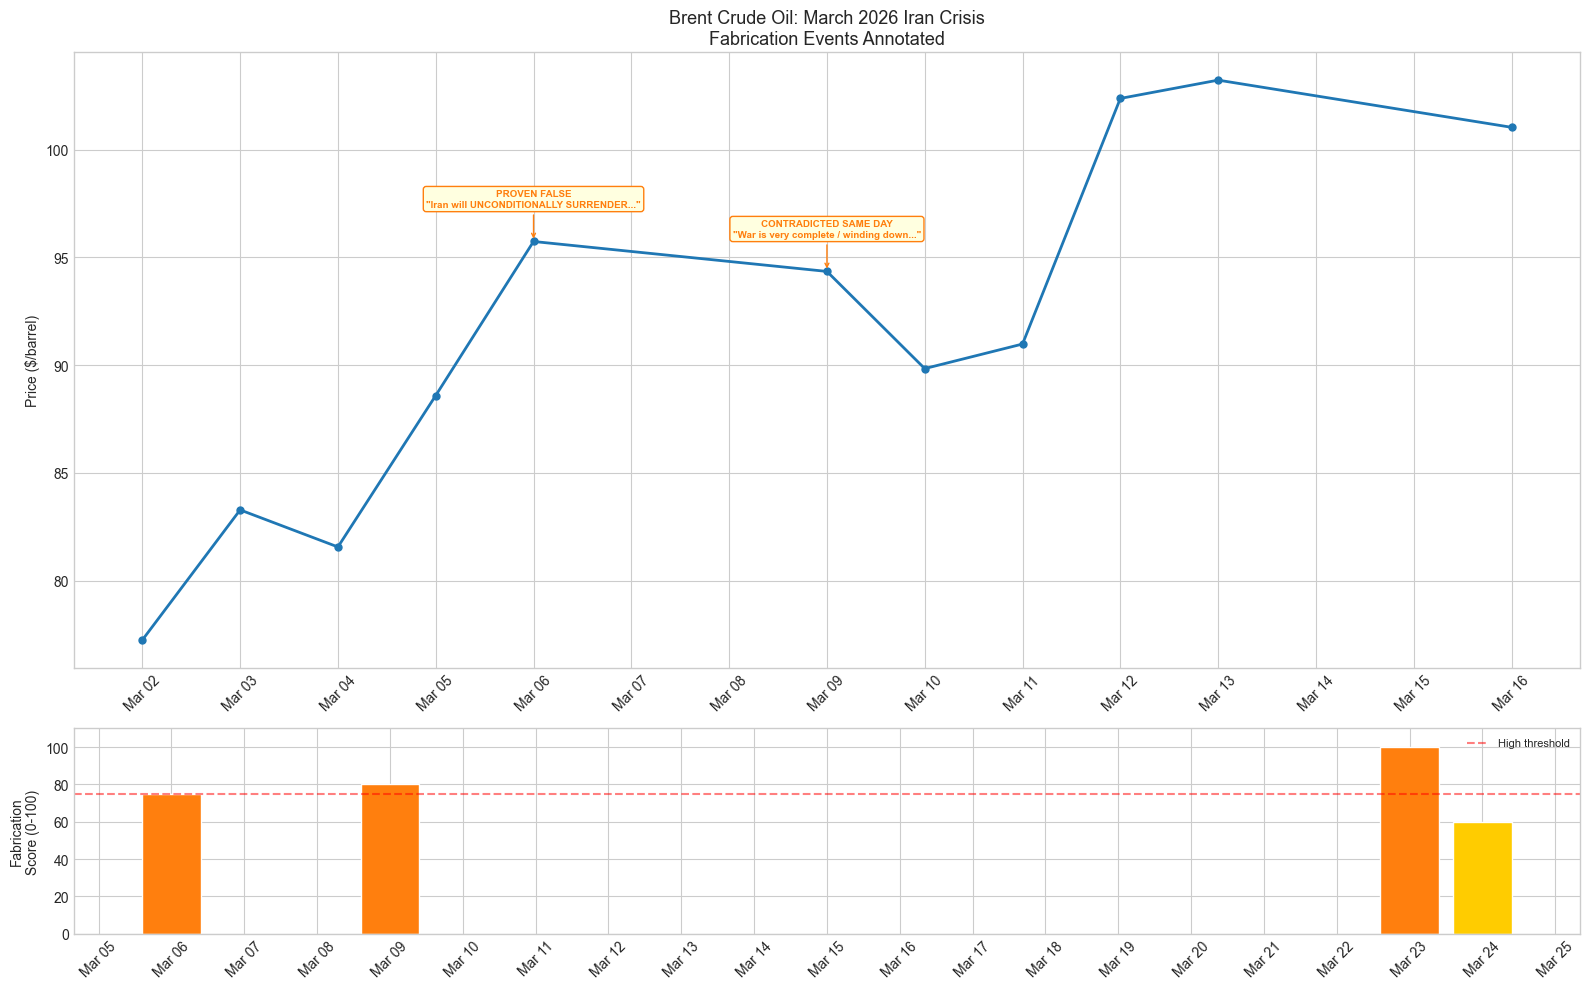

In [4]:
# Visualization: Fabrication Timeline
fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1]})

# Top: Oil price during Iran crisis
crisis = master[(master['date'] >= '2026-03-01') & (master['date'] <= '2026-03-24')]
crisis_trading = crisis[crisis['is_trading_day'] == 1]

axes[0].plot(crisis_trading['date'], crisis_trading['brent_close'], 
             color=COLORS['oil_price'], linewidth=2, marker='o', markersize=5)

# Mark fabrication events
for _, fab in fabrication_evidence.iterrows():
    # Find closest trading day
    closest = crisis_trading.iloc[(crisis_trading['date'] - fab['date']).abs().argsort()[:1]]
    if len(closest) > 0:
        price = closest.iloc[0]['brent_close']
        if pd.notna(price):
            axes[0].annotate(
                f'{fab["verification_status"]}\n"{fab["trump_claim"][:40]}..."',
                xy=(fab['date'], price),
                xytext=(0, 25),
                textcoords='offset points',
                fontsize=7,
                ha='center',
                color=COLORS['fabrication'],
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor=COLORS['fabrication']),
                arrowprops=dict(arrowstyle='->', color=COLORS['fabrication'])
            )

axes[0].set_title('Brent Crude Oil: March 2026 Iran Crisis\nFabrication Events Annotated', fontsize=13)
axes[0].set_ylabel('Price ($/barrel)')
axes[0].xaxis.set_major_locator(mdates.DayLocator(interval=1))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45)

# Bottom: Fabrication score bar chart
bar_colors = [COLORS['fabrication'] if s >= 75 else '#ffcc00' if s >= 50 else '#99cc99' 
              for s in fabrication_evidence['fabrication_score']]
axes[1].bar(fabrication_evidence['date'], fabrication_evidence['fabrication_score'], 
            width=0.8, color=bar_colors, edgecolor='white')
axes[1].set_ylabel('Fabrication\nScore (0-100)')
axes[1].set_ylim(0, 110)
axes[1].axhline(y=75, color='red', linestyle='--', alpha=0.5, label='High threshold')
axes[1].xaxis.set_major_locator(mdates.DayLocator(interval=1))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../data/processed/fig_fabrication_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Deep dive: March 23 Smoking Gun
print('=== THE SMOKING GUN: MARCH 23, 2026 ===')
print()
print('SEQUENCE OF EVENTS:')
print('1. March 22: Trump posts "OBLITERATE" threat → oil spikes')
print('2. March 22-23: Trump posts about "productive conversations" with Iran')
print('3. Oil drops 13%+ on de-escalation hopes')
print('4. Iran\'s Foreign Ministry DENIES any talks took place')
print('5. Iran explicitly accuses Trump of using "fake news to manipulate')
print('   the financial and oil markets"')
print()
print('WHY THIS IS MANIPULATION:')
print('- A factual claim was made (diplomatic talks with Iran)')
print('- The claim was specific and verifiable')
print('- Markets moved significantly BEFORE the truth emerged')
print('- The counterparty (Iran) explicitly denied it')
print('- Iran explicitly identified the purpose as market manipulation')
print('- Anyone with short positions in oil profited from the fabrication')

=== THE SMOKING GUN: MARCH 23, 2026 ===

SEQUENCE OF EVENTS:
1. March 22: Trump posts "OBLITERATE" threat → oil spikes
2. March 22-23: Trump posts about "productive conversations" with Iran
3. Oil drops 13%+ on de-escalation hopes
4. Iran's Foreign Ministry DENIES any talks took place
5. Iran explicitly accuses Trump of using "fake news to manipulate
   the financial and oil markets"

WHY THIS IS MANIPULATION:
- A factual claim was made (diplomatic talks with Iran)
- The claim was specific and verifiable
- Markets moved significantly BEFORE the truth emerged
- The counterparty (Iran) explicitly denied it
- Iran explicitly identified the purpose as market manipulation
- Anyone with short positions in oil profited from the fabrication


## PART B: Causality Analysis (Vector 3)

The critical question: Did the post come BEFORE the price move (manipulation)
or AFTER (reactive)?

With daily data, we can show that oil prices moved significantly on post days.
With intraday data (if available), we can narrow this to minutes.

In [6]:
# Daily causality: price changes on post days vs. non-post days
trading = master[master['is_trading_day'] == 1].copy()

# Next-day return after oil posts
trading['next_day_return'] = trading['brent_pct_change'].shift(-1)

post_days = trading[trading['oil_post_count'] > 0]
no_post_days = trading[trading['oil_post_count'] == 0]

print('=== DAILY CAUSALITY ANALYSIS ===')
print(f'\nSame-day returns:')
print(f'  Post days mean: {post_days["brent_pct_change"].mean():.3f}%')
print(f'  No-post days mean: {no_post_days["brent_pct_change"].mean():.3f}%')
print(f'  Post days abs mean: {post_days["brent_pct_change"].abs().mean():.3f}%')
print(f'  No-post days abs mean: {no_post_days["brent_pct_change"].abs().mean():.3f}%')

print(f'\nNext-day returns (after post):')
print(f'  After post day mean: {post_days["next_day_return"].mean():.3f}%')
print(f'  After no-post day mean: {no_post_days["next_day_return"].mean():.3f}%')

=== DAILY CAUSALITY ANALYSIS ===

Same-day returns:
  Post days mean: 0.129%
  No-post days mean: -0.011%
  Post days abs mean: 1.696%
  No-post days abs mean: 0.991%

Next-day returns (after post):
  After post day mean: 0.147%
  After no-post day mean: -0.247%


In [7]:
# Directional causality: Do escalation posts predict price UP and de-escalation DOWN?
print('=== DIRECTIONAL CAUSALITY ===')

for direction in ['escalation', 'de_escalation']:
    subset = trading[trading['dominant_direction'] == direction]
    if len(subset) > 0:
        print(f'\n{direction.upper()} post days ({len(subset)} days):')
        print(f'  Same-day mean return: {subset["brent_pct_change"].mean():.3f}%')
        print(f'  Next-day mean return: {subset["next_day_return"].mean():.3f}%')
        print(f'  Same-day median return: {subset["brent_pct_change"].median():.3f}%')
        
        # Expected direction check
        if direction == 'escalation':
            correct_direction = (subset['brent_pct_change'] > 0).mean() * 100
            print(f'  % of days price went UP: {correct_direction:.1f}%')
        else:
            correct_direction = (subset['brent_pct_change'] < 0).mean() * 100
            print(f'  % of days price went DOWN: {correct_direction:.1f}%')

=== DIRECTIONAL CAUSALITY ===

ESCALATION post days (100 days):
  Same-day mean return: 0.604%
  Next-day mean return: 0.154%
  Same-day median return: 0.524%
  % of days price went UP: 52.0%

DE_ESCALATION post days (132 days):
  Same-day mean return: -0.166%
  Next-day mean return: 0.283%
  Same-day median return: -0.190%
  % of days price went DOWN: 52.3%


In [8]:
# Intraday causality (if data available)
import os

intraday_available = False
intraday_file = '../data/raw/uso_intraday.csv'
eodhd_file = '../data/raw/oil_intraday_eodhd.csv'

if os.path.exists(eodhd_file):
    intraday = pd.read_csv(eodhd_file)
    intraday['timestamp'] = pd.to_datetime(intraday['timestamp'])
    intraday_available = True
    print(f'Using EODHD intraday data: {len(intraday)} bars')
elif os.path.exists(intraday_file):
    intraday = pd.read_csv(intraday_file)
    intraday['timestamp'] = pd.to_datetime(intraday['timestamp'])
    intraday_available = True
    print(f'Using USO ETF intraday data: {len(intraday)} bars')
else:
    print('No intraday data available. Using daily-only causality analysis.')
    print('Causality scores will be based on same-day and next-day price moves.')

Using USO ETF intraday data: 4491 bars


In [9]:
def calculate_causality_score_daily(row):
    """
    Calculate causality score using daily data.
    
    Higher scores for larger price moves on post days.
    """
    if row['oil_post_count'] == 0:
        return 0
    
    same_day = abs(row['brent_pct_change']) if pd.notna(row['brent_pct_change']) else 0
    next_day = abs(row['next_day_return']) if pd.notna(row['next_day_return']) else 0
    
    # Larger moves = stronger evidence of causation
    max_move = max(same_day, next_day)
    
    if max_move > 10:
        return 100
    elif max_move > 5:
        return 80
    elif max_move > 2:
        return 60
    elif max_move > 1:
        return 40
    else:
        return 20

trading['causality_score'] = trading.apply(calculate_causality_score_daily, axis=1)

high_causality = trading[trading['causality_score'] >= 60]
print(f'Days with high causality score (>=60): {len(high_causality)}')
if len(high_causality) > 0:
    print(high_causality[['date', 'brent_pct_change', 'next_day_return', 'oil_post_count', 'causality_score']].to_string())

Days with high causality score (>=60): 134
          date  brent_pct_change  next_day_return  oil_post_count  causality_score
9   2025-01-10          1.682815         3.673521               1               60
35  2025-02-05         -2.441891        -0.227547               3               60
37  2025-02-07          0.187819         2.075522               1               60
40  2025-02-10          2.075522         1.862784               2               60
41  2025-02-11          1.862784        -2.923374               5               60
42  2025-02-12         -2.923374         0.305121               3               60
50  2025-02-20          0.799057        -2.690058               5               60
51  2025-02-21         -2.690058         0.013355               1               60
54  2025-02-24          0.013355        -2.376819               4               60
55  2025-02-25         -2.376819         0.519765               3               60
56  2025-02-26          0.519765         2.0

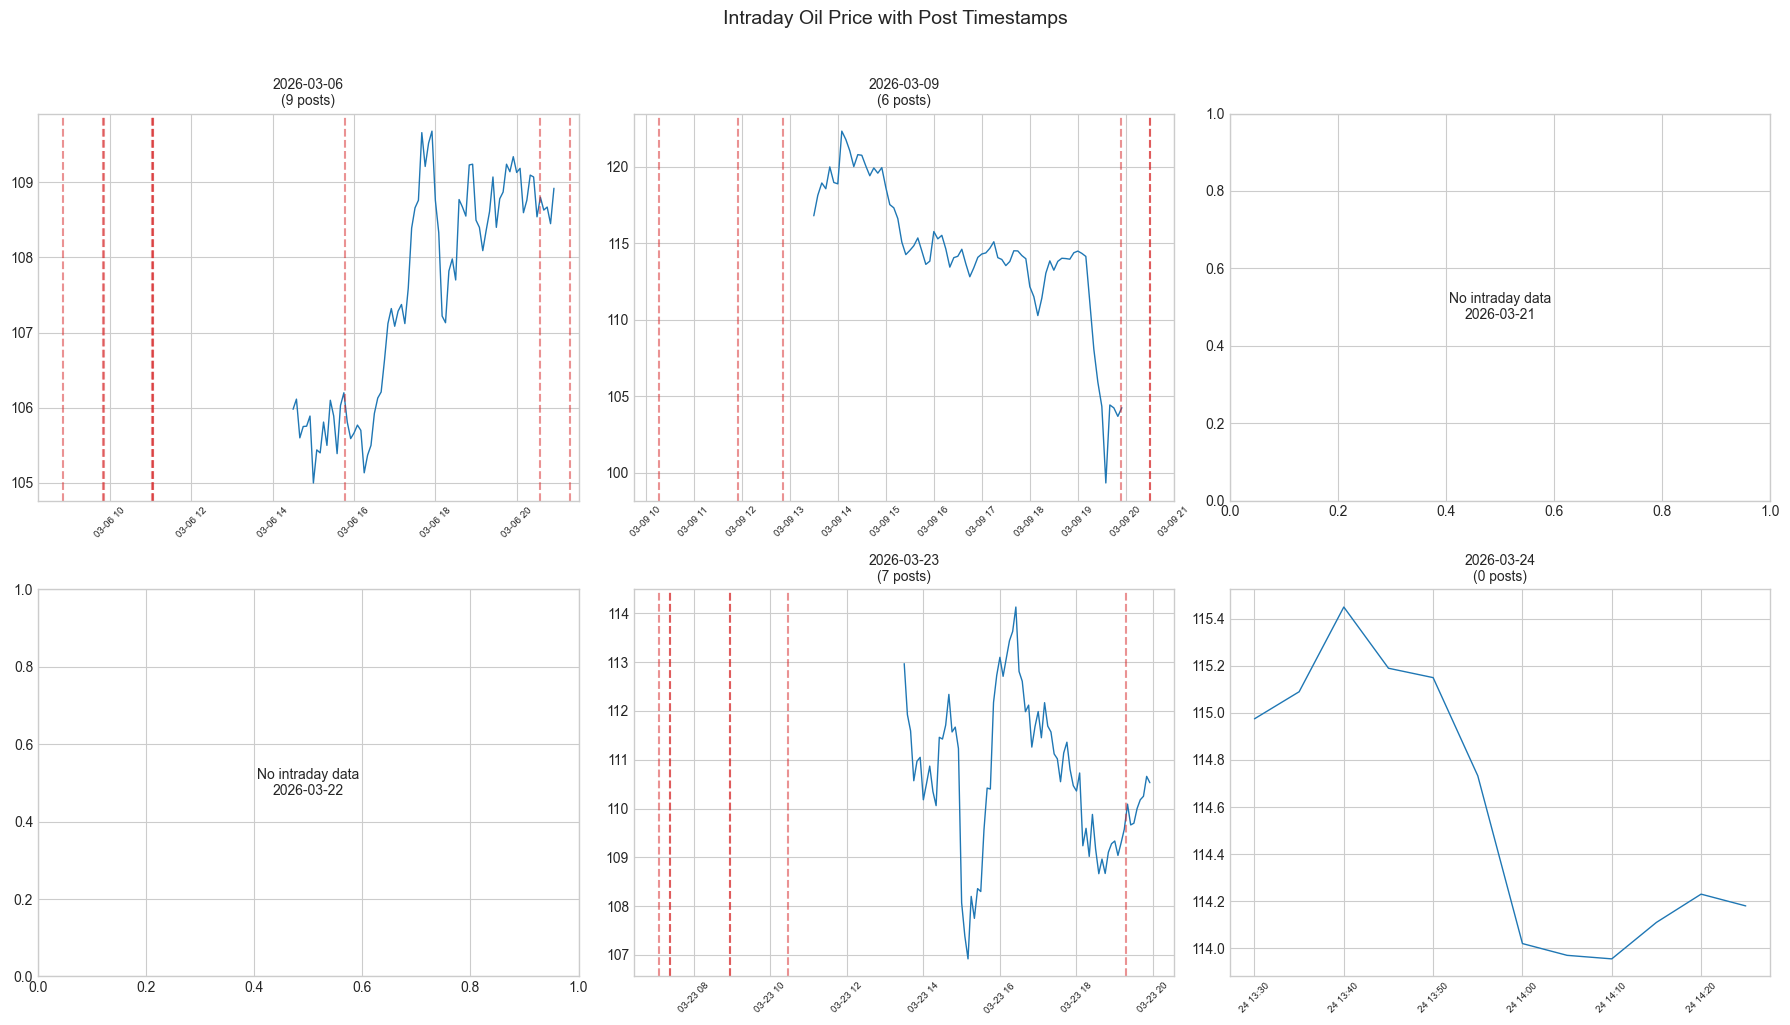

In [10]:
# If intraday data is available, create detailed causality charts for key dates
if intraday_available:
    key_posts = posts[(posts['is_oil_related'] == True) & 
                      (posts['date'] >= '2026-03-06') & 
                      (posts['date'] <= '2026-03-24')]
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    key_dates = ['2026-03-06', '2026-03-09', '2026-03-21', 
                 '2026-03-22', '2026-03-23', '2026-03-24']
    
    for idx, date_str in enumerate(key_dates):
        if idx >= len(axes):
            break
        
        date = pd.Timestamp(date_str)
        day_data = intraday[intraday['timestamp'].dt.date == date.date()]
        
        if len(day_data) == 0:
            axes[idx].text(0.5, 0.5, f'No intraday data\n{date_str}', 
                          ha='center', va='center', transform=axes[idx].transAxes)
            continue
        
        # Plot intraday price
        close_col = [c for c in day_data.columns if 'close' in c.lower()]
        if close_col:
            axes[idx].plot(day_data['timestamp'], day_data[close_col[0]], 
                          color=COLORS['oil_price'], linewidth=1)
        
        # Mark post times
        day_posts = key_posts[key_posts['date'].dt.date == date.date()]
        for _, post in day_posts.iterrows():
            axes[idx].axvline(post['timestamp'], color=COLORS['escalation'], 
                            alpha=0.5, linestyle='--')
        
        axes[idx].set_title(f'{date_str}\n({len(day_posts)} posts)', fontsize=10)
        axes[idx].tick_params(axis='x', rotation=45, labelsize=7)
    
    plt.suptitle('Intraday Oil Price with Post Timestamps', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('../data/processed/fig_intraday_causality.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipping intraday visualization (no intraday data available).')

In [11]:
# Save fabrication scores and causality scores
fabrication_evidence.to_csv('../data/processed/fabrication_evidence.csv', index=False)

causality_scores = trading[['date', 'causality_score']].copy()
causality_scores.to_csv('../data/processed/causality_scores.csv', index=False)

print(f'Saved fabrication evidence: {len(fabrication_evidence)} events')
print(f'Saved causality scores: {len(causality_scores)} trading days')
print('\nNext step: Run notebook 06 for composite manipulation score.')

Saved fabrication evidence: 4 events
Saved causality scores: 305 trading days

Next step: Run notebook 06 for composite manipulation score.
